<a href="https://colab.research.google.com/github/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*Can five historical search-performance features reliably rank client-content pages that will experience a substantial decline in future daily impressions, particularly for completely unseen clients? The operational decision supported by this research is which twenty pages a human analyst should investigate first.*

In [ ]:
RESEARCH_CONFIG = {
    "question": (
        "Can historical search signals prioritize future "
        "impression-decline risk for unseen clients?"
    ),
    "decision": "Rank a Top-20 human-review queue",
    "primary_metric": "Precision@20",
    "decision_moment": "2026-03-21",
    "automation_allowed": False,
}

RESEARCH_CONFIG

{'question': 'Can historical search signals prioritize future impression-decline risk for unseen clients?',
 'decision': 'Rank a Top-20 human-review queue',
 'primary_metric': 'Precision@20',
 'decision_moment': '2026-03-21',
 'automation_allowed': False}

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
import pandas as pd

data_summary = pd.DataFrame({
    "Item": [
        "Warehouse",
        "Table",
        "Feature window",
        "Outcome window",
        "Eligible rows",
        "Pseudonymous clients",
        "Sealed period"
    ],
    "Value": [
        "FlyRank Internship Warehouse",
        "fact_content_daily_performance",
        "2026-03-01 to 2026-03-21",
        "2026-03-22 to 2026-03-31",
        2348,
        14,
        "June 2026"
    ]
})

data_summary

,Item,Value
0,Warehouse,FlyRank Internship Warehouse
1,Table,fact_content_daily_performance
2,Feature window,2026-03-01 to 2026-03-21
3,Outcome window,2026-03-22 to 2026-03-31
4,Eligible rows,2348
5,Pseudonymous clients,14
6,Sealed period,June 2026


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
methodology = pd.DataFrame([
    ["Label", "Outcome impressions/day < 80% of historical impressions/day"],
    ["Features", "5 historical, pre-decision numerical features"],
    ["Baseline", "Transparent weighted rule"],
    ["Primary model", "Logistic Regression"],
    ["Challenger", "Constrained Random Forest"],
    ["Validation", "Client-grouped holdout"],
    ["Primary metric", "Precision@20"],
    ["Client overlap", "0"]
], columns=["Component", "Definition"])

methodology

,Component,Definition
0,Label,Outcome impressions/day < 80% of historical im...
1,Features,"5 historical, pre-decision numerical features"
2,Baseline,Transparent weighted rule
3,Primary model,Logistic Regression
4,Challenger,Constrained Random Forest
5,Validation,Client-grouped holdout
6,Primary metric,Precision@20
7,Client overlap,0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

,Method,Precision@20,Precision@50,Average Precision,ROC-AUC
0,Baseline,0.0,0.04,0.0478,0.3955
1,Logistic Regression,0.0,0.04,0.0461,0.3284
2,Random Forest,0.0,0.02,0.0591,0.5120


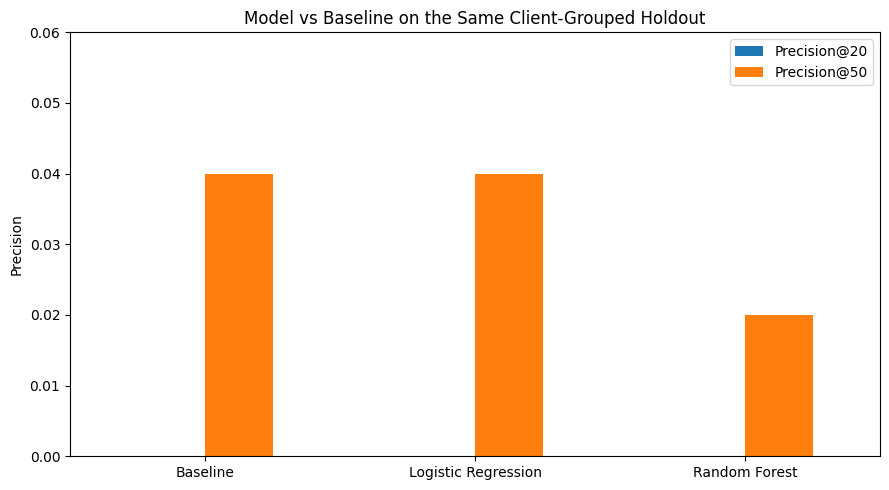

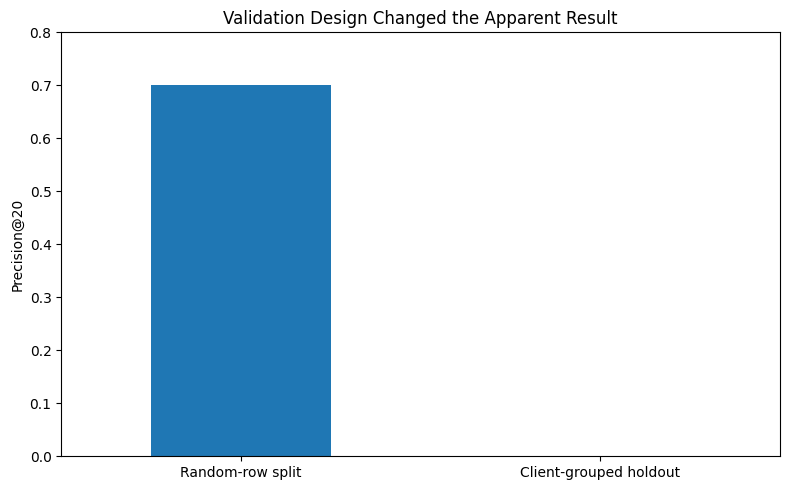

Charts saved in: /content/docs/assets


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision@20": [0.00, 0.00, 0.00],
    "Precision@50": [0.04, 0.04, 0.02],
    "Average Precision": [0.0478, 0.0461, 0.0591],
    "ROC-AUC": [0.3955, 0.3284, 0.5120]
})

display(results)

repo_candidates = [
    Path("/content/flyrank-ml-internship"),
    Path.cwd()
]

repo_root = next(
    (path for path in repo_candidates if (path / "work").exists()),
    Path.cwd()
)

assets_dir = repo_root / "docs" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)

# Figure 1: Operational ranking metrics
ax = results.set_index("Method")[
    ["Precision@20", "Precision@50"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Model vs Baseline on the Same Client-Grouped Holdout")
ax.set_ylabel("Precision")
ax.set_xlabel("")
ax.set_ylim(0, 0.06)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(
    assets_dir / "model-vs-baseline.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

# Figure 2: Validation-design gap
validation_comparison = pd.DataFrame({
    "Validation design": [
        "Random-row split",
        "Client-grouped holdout"
    ],
    "Precision@20": [0.70, 0.00],
    "Overlapping clients": [12, 0]
})

ax = validation_comparison.plot(
    x="Validation design",
    y="Precision@20",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("Validation Design Changed the Apparent Result")
ax.set_ylabel("Precision@20")
ax.set_xlabel("")
ax.set_ylim(0, 0.80)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(
    assets_dir / "validation-design-gap.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

print(f"Charts saved in: {assets_dir}")

## 5. Limitations and Honest Framing

This study has several limitations that affect how the results should be interpreted.

### 1. Short analysis period

The analysis used only the March 2026 development period. The feature window covered March 1 to March 21, 2026, and the outcome window covered March 22 to March 31, 2026.

Because the outcome window contains only ten days, temporary ranking changes, reporting delays, seasonality, search-demand changes, and short-term volatility may affect the decline label.

The results may change when the same method is evaluated over longer 30-day, 60-day, or 90-day outcome windows.

### 2. Small client-grouped test set

The client-grouped test set contained 228 client-content rows from four unseen pseudonymous clients.

This validation design was more honest than a random-row split because no client appeared in both training and testing. However, four held-out clients are not enough to claim that the model will generalize across all clients, industries, content types, or search environments.

### 3. Low number of positive examples

The grouped test set contained only thirteen proxy-positive pages, resulting in a positive base rate of approximately 5.7%.

Because the number of positive examples was small, Precision@20 may be unstable. A different selection of held-out clients or a different outcome period could produce substantially different results.

### 4. The target is only a proxy label

A page was labelled as declining when its average daily impressions during the outcome window fell below 80% of its average daily impressions during the historical feature window.

This label measures short-term impression decline. It does not identify the reason for the decline.

Possible causes may include:

* changing search demand;
* seasonality;
* ranking volatility;
* technical SEO problems;
* indexing issues;
* search-intent changes;
* competitor activity;
* content quality;
* algorithm updates; or
* measurement noise.

The label also does not prove that a page requires a content refresh.

### 5. Limited feature set

The models used only five historical features:

* historical impressions per day;
* historical clicks per day;
* historical click-through rate;
* historical average position; and
* historical position standard deviation.

The models did not include several potentially useful factors, including:

* content age;
* time since the last meaningful update;
* content category;
* search-query intent;
* technical SEO health;
* backlinks or authority signals;
* content quality;
* competitor changes;
* business value;
* seasonality; and
* editorial history.

Therefore, the current model may not capture the full set of factors that influence search-performance decline.

### 6. Observational study design

This research is observational.

Pages were not randomly assigned to receive a refresh, rewrite, technical repair, title change, consolidation, or any other intervention.

Therefore, the results cannot prove that modifying a selected page would cause impressions or traffic to recover. The model only attempts to prioritize pages for investigation based on observed historical patterns.

### 7. Random-row validation was misleading

The random-row diagnostic produced Precision@20 of 0.700. However, twelve clients appeared in both the training and test sets.

This client overlap allowed client-specific patterns to cross the validation boundary and made the result unsuitable as evidence of real-world generalization.

When the evaluation used a client-grouped holdout with zero client overlap, Precision@20 fell to 0.000.

For this reason, the client-grouped result is treated as the primary and more trustworthy evaluation.

### 8. No model outperformed the baseline

On the same client-grouped holdout:

* the transparent baseline achieved Precision@20 of 0.000;
* Logistic Regression achieved Precision@20 of 0.000; and
* Random Forest achieved Precision@20 of 0.000.

Logistic Regression also measured ROC-AUC of 0.3284, while Random Forest measured ROC-AUC of 0.5120.

Although Random Forest had a higher ROC-AUC and Average Precision, it did not improve the operational Top-20 review queue.

Therefore, the available evidence does not show that either learned model provides a useful operational improvement over the transparent baseline.

### 9. No out-of-time validation

The model was not validated on a later independent month.

June 2026 remained sealed and was not used during development. This prevented accidental test-period leakage, but it also means that the current paper does not contain a true out-of-time result.

A later period should be used only after the complete modeling and evaluation process has been finalized.

### 10. Public-safe data limits interpretation

The public research artifact excludes client names, domains, page URLs, raw queries, keywords, and confidential business information.

This protects privacy and makes the paper safe for public deployment. However, it also prevents readers from independently examining page-level context, search intent, business importance, or specific causes of performance decline.

### Final limitation statement

The results provide directional evidence from one short March 2026 experiment. They do not prove that the model generalizes to all clients, that a selected page requires modification, or that any content intervention would cause search-performance recovery.

The current model should remain an experimental and human-reviewed decision-support tool. Automatic production deployment is not supported by the available evidence.


In [ ]:
import pandas as pd

limitations = pd.DataFrame([
    {
        "limitation": "Short outcome window",
        "evidence": "Outcome window covers only 2026-03-22 to 2026-03-31",
        "impact": "Short-term volatility and seasonality may affect the label"
    },
    {
        "limitation": "Small grouped test set",
        "evidence": "228 rows from 4 unseen pseudonymous clients",
        "impact": "Results cannot be broadly generalized"
    },
    {
        "limitation": "Few positive cases",
        "evidence": "13 positives; test base rate approximately 0.057",
        "impact": "Precision@20 may be unstable"
    },
    {
        "limitation": "Proxy target",
        "evidence": (
            "Positive label means outcome impressions/day were below "
            "80% of historical impressions/day"
        ),
        "impact": "The label does not identify the cause of decline"
    },
    {
        "limitation": "Limited feature set",
        "evidence": "Only 5 historical search-performance features",
        "impact": (
            "Content age, intent, technical health, seasonality, "
            "and editorial history are not represented"
        )
    },
    {
        "limitation": "Observational design",
        "evidence": "No randomized content intervention",
        "impact": "No causal claim about refresh or traffic recovery is supported"
    },
    {
        "limitation": "Validation-design sensitivity",
        "evidence": (
            "Random-row Precision@20 = 0.700 with 12 overlapping clients; "
            "grouped Precision@20 = 0.000 with zero overlap"
        ),
        "impact": "Random-row performance was not reliable evidence of generalization"
    },
    {
        "limitation": "No out-of-time test",
        "evidence": "June 2026 remained sealed and unused",
        "impact": "Temporal generalization has not yet been demonstrated"
    }
])

display(limitations)

claim_status = {
    "causal_claim_supported": False,
    "automatic_deployment_supported": False,
    "broad_generalization_supported": False,
    "human_review_required": True
}

assert claim_status["causal_claim_supported"] is False
assert claim_status["automatic_deployment_supported"] is False
assert claim_status["broad_generalization_supported"] is False
assert claim_status["human_review_required"] is True

print("Number of documented limitations:", len(limitations))
print("Causal claims supported:", claim_status["causal_claim_supported"])
print(
    "Final framing: directional evidence only; "
    "production automation remains blocked."
)

,limitation,evidence,impact
0,Short outcome window,Outcome window covers only 2026-03-22 to 2026-...,Short-term volatility and seasonality may affe...
1,Small grouped test set,228 rows from 4 unseen pseudonymous clients,Results cannot be broadly generalized
2,Few positive cases,13 positives; test base rate approximately 0.057,Precision@20 may be unstable
3,Proxy target,Positive label means outcome impressions/day w...,The label does not identify the cause of decline
4,Limited feature set,Only 5 historical search-performance features,"Content age, intent, technical health, seasona..."
5,Observational design,No randomized content intervention,No causal claim about refresh or traffic recov...
6,Validation-design sensitivity,Random-row Precision@20 = 0.700 with 12 overla...,Random-row performance was not reliable eviden...
7,No out-of-time test,June 2026 remained sealed and unused,Temporal generalization has not yet been demon...


Number of documented limitations: 8
Causal claims supported: False
Final framing: directional evidence only; production automation remains blocked.


## 6. Ranked Recommendations

The honest client-grouped validation showed that the Logistic Regression model, Random Forest model, and transparent baseline all achieved a Precision@20 of 0.000 on unseen clients. Therefore, the model should not be used for automatic production decisions. The recommended action is to use a transparent, human-reviewed prioritization system while collecting stronger validation evidence.

### 1. Block automatic production deployment

The current model should not automatically refresh, rewrite, delete, consolidate, or modify any page.

It should also not automatically send client-facing recommendations because the model did not demonstrate reliable Top-20 performance on unseen clients.

The model may be retained only for research, auditing, and experimental triage.

### 2. Use a transparent human-review queue

Pages should be prioritized using understandable historical signals rather than relying only on model probabilities.

The review queue should consider:

* high historical impressions;
* low historical click-through rate;
* average search position between 4 and 20;
* high position volatility; and
* estimated business value or review priority.

Each page should include clear reason codes explaining why it was selected.

### 3. Apply ranked review dispositions

Every page in the queue should receive one of the following dispositions:

1. **REVIEW** — the page has high value and an actionable performance pattern.
2. **INVESTIGATE** — technical, indexing, measurement, ranking, or query-level causes should be checked before editing.
3. **EXPERIMENTAL_TRIAGE** — the model assigned a high risk score, but transparent evidence is weak.
4. **MONITOR** — the page has value, but current evidence does not justify an immediate change.
5. **DEFER** — the page has low current priority or insufficient evidence for review.

### 4. Match reason codes with human actions

The following action policy should be used:

* **High demand:** preserve the page and perform a careful review because an incorrect change could affect valuable traffic.
* **Low CTR:** review the page title, meta description, search intent, structured data, and SERP presentation.
* **Position between 4 and 20:** review content depth, internal linking, topical coverage, and intent alignment.
* **High position volatility:** investigate indexing, technical SEO, keyword cannibalization, query changes, and ranking instability.
* **Weak position:** perform a deeper relevance, competition, authority, and content-quality review.
* **Model-only flag:** keep the page in experimental triage and do not automatically recommend changes.

### 5. Treat content freshness as a hypothesis

A page should not be refreshed only because it is old.

Before recommending a refresh, a reviewer should verify:

* the date of the last meaningful update;
* outdated facts, statistics, links, or screenshots;
* changes in search intent;
* technical health;
* current business relevance;
* content duplication;
* editorial history; and
* whether the page still satisfies the user’s search need.

Freshness should remain a human-reviewed hypothesis rather than an automatic action.

### 6. Improve the feature set

Future versions of the model should consider additional pre-decision and public-safe features, including:

* content age;
* time since the last meaningful update;
* historical performance trend;
* week-over-week volatility;
* month-over-month volatility;
* content category;
* query diversity;
* branded versus non-branded demand;
* device distribution;
* country distribution;
* technical availability signals;
* anonymized engagement measures; and
* anonymized business-value categories.

Every new feature must be available before the decision moment and must pass leakage and privacy checks.

### 7. Perform stronger validation

Before reconsidering production deployment, the project should include:

* more held-out clients;
* repeated group-based cross-validation;
* out-of-time validation on a later period;
* confidence intervals for Precision@20;
* minimum positive-case requirements;
* probability calibration;
* performance analysis by client size;
* performance analysis by content category;
* multiple label thresholds; and
* multiple feature and outcome windows.

### 8. Measure real intervention outcomes

Future work should measure what happens after human-reviewed actions.

Pages may be divided into groups such as:

* refreshed pages;
* technically repaired pages;
* title or snippet experiments;
* consolidated pages;
* monitored pages; and
* untreated comparison pages.

Performance should then be measured over consistent 30-day and 60-day periods.

This would provide stronger evidence about whether the prioritization process and recommended actions lead to useful outcomes.

### Final Recommendation

The current model is not approved for automated deployment. The safest operational approach is a transparent, reason-coded human-review queue. The model should remain an experimental decision-support signal until it demonstrates reliable improvement on larger client-grouped and out-of-time validation sets.


In [ ]:
import pandas as pd

recommendations = pd.DataFrame([
    {
        "rank": 1,
        "recommendation": "Block automatic production deployment",
        "reason": (
            "Baseline, Logistic Regression, and Random Forest all achieved "
            "Precision@20 = 0.000 on the unseen-client holdout."
        ),
        "action": (
            "Do not automatically refresh, rewrite, delete, consolidate, "
            "or modify pages."
        )
    },
    {
        "rank": 2,
        "recommendation": "Use a transparent human-review queue",
        "reason": (
            "Transparent historical signals are easier to inspect and explain "
            "than an unvalidated model probability."
        ),
        "action": (
            "Rank pages using demand, CTR, position opportunity, volatility, "
            "and estimated business value."
        )
    },
    {
        "rank": 3,
        "recommendation": "Separate review dispositions",
        "reason": (
            "Different performance patterns require different investigation "
            "and review actions."
        ),
        "action": (
            "Assign REVIEW, INVESTIGATE, EXPERIMENTAL_TRIAGE, MONITOR, or DEFER."
        )
    },
    {
        "rank": 4,
        "recommendation": "Treat freshness as a hypothesis",
        "reason": (
            "Page age alone does not prove that refreshing content will "
            "improve search performance."
        ),
        "action": (
            "Manually verify staleness, intent drift, factual ageing, "
            "technical health, and business relevance."
        )
    },
    {
        "rank": 5,
        "recommendation": "Expand the honest feature set",
        "reason": (
            "The current five historical features do not capture content age, "
            "technical health, intent, seasonality, or editorial history."
        ),
        "action": (
            "Add only pre-decision, public-safe features that pass leakage "
            "and privacy checks."
        )
    },
    {
        "rank": 6,
        "recommendation": "Run stronger validation",
        "reason": (
            "The current grouped holdout contains only 228 rows from four "
            "unseen clients."
        ),
        "action": (
            "Use more held-out clients, grouped cross-validation, out-of-time "
            "testing, and uncertainty intervals."
        )
    },
    {
        "rank": 7,
        "recommendation": "Measure real intervention outcomes",
        "reason": (
            "The current study predicts a decline proxy but does not measure "
            "the causal effect of content changes."
        ),
        "action": (
            "Track reviewed, refreshed, repaired, monitored, and untreated "
            "pages over 30-day and 60-day periods."
        )
    }
])

recommendations = recommendations.sort_values("rank").reset_index(drop=True)

display(recommendations)

production_gate = "BLOCKED"

assert production_gate == "BLOCKED"
assert recommendations["rank"].is_monotonic_increasing
assert recommendations["rank"].nunique() == len(recommendations)

print("Production gate:", production_gate)
print("Number of ranked recommendations:", len(recommendations))
print(
    "Final decision: use a transparent human-reviewed queue "
    "and retain the model for experimental analysis only."
)

,rank,recommendation,reason,action
0,1,Block automatic production deployment,"Baseline, Logistic Regression, and Random Fore...","Do not automatically refresh, rewrite, delete,..."
1,2,Use a transparent human-review queue,Transparent historical signals are easier to i...,"Rank pages using demand, CTR, position opportu..."
2,3,Separate review dispositions,Different performance patterns require differe...,"Assign REVIEW, INVESTIGATE, EXPERIMENTAL_TRIAG..."
3,4,Treat freshness as a hypothesis,Page age alone does not prove that refreshing ...,"Manually verify staleness, intent drift, factu..."
4,5,Expand the honest feature set,The current five historical features do not ca...,"Add only pre-decision, public-safe features th..."
5,6,Run stronger validation,The current grouped holdout contains only 228 ...,"Use more held-out clients, grouped cross-valid..."
6,7,Measure real intervention outcomes,The current study predicts a decline proxy but...,"Track reviewed, refreshed, repaired, monitored..."


Production gate: BLOCKED
Number of ranked recommendations: 7
Final decision: use a transparent human-reviewed queue and retain the model for experimental analysis only.


## 7. Artifacts the Paper Embeds

The deployed research paper includes a small set of tables and charts that communicate the main findings without exposing private client information.

Each artifact supports one specific research claim. All results shown in the paper come from the completed notebooks in this repository.

### Artifact 1 — Data and Validation Summary

The first artifact summarizes the modeling dataset and honest validation design.

| Item                          |        Value |
| ----------------------------- | -----------: |
| Eligible client-content rows  |        2,348 |
| Eligible pseudonymous clients |           14 |
| Training rows                 |        2,120 |
| Training clients              |           10 |
| Test rows                     |          228 |
| Unseen test clients           |            4 |
| Training-test client overlap  |            0 |
| Test positive base rate       |        0.057 |
| Historical feature count      |            5 |
| Primary metric                | Precision@20 |

This table shows that the final evaluation used completely unseen clients. No client appeared in both the training and test sets.

### Artifact 2 — Model Versus Baseline Results

The second artifact compares the transparent baseline, Logistic Regression, and Random Forest on exactly the same client-grouped holdout.

| Method               | Precision@20 | Precision@50 | Average Precision | ROC-AUC |
| -------------------- | -----------: | -----------: | ----------------: | ------: |
| Transparent baseline |        0.000 |        0.040 |            0.0478 |  0.3955 |
| Logistic Regression  |        0.000 |        0.040 |            0.0461 |  0.3284 |
| Random Forest        |        0.000 |        0.020 |            0.0591 |  0.5120 |

**Takeaway:** None of the methods selected a proxy-positive page within the first twenty recommendations on the unseen-client holdout.

Random Forest produced the highest ROC-AUC and Average Precision, but it did not improve the operational Precision@20 metric. Logistic Regression remained the preferred learned model because Random Forest did not justify its additional complexity.

However, the preferred model is not approved for production deployment.

### Artifact 3 — Operational Precision Chart

The paper includes a bar chart comparing Precision@20 and Precision@50 across the three methods.

The chart uses the same held-out rows for every method.

**Takeaway:** The transparent baseline and Logistic Regression tied at Precision@50 of 0.040, while Random Forest achieved 0.020. All three methods achieved Precision@20 of 0.000.

The chart is saved as:

`docs/assets/model-vs-baseline.png`

### Artifact 4 — Validation Design Comparison

The paper includes a chart comparing the random-row diagnostic with the client-grouped holdout.

| Validation design      | Precision@20 | Overlapping clients |
| ---------------------- | -----------: | ------------------: |
| Random-row split       |        0.700 |                  12 |
| Client-grouped holdout |        0.000 |                   0 |

**Takeaway:** The apparently strong random-row result disappeared when client overlap was removed.

The random-row split was not accepted as the final evaluation because client-specific patterns could appear in both training and testing. The client-grouped result is treated as the primary and more trustworthy result.

The chart is saved as:

`docs/assets/validation-design-gap.png`

### Artifact 5 — Ranked Recommendations Table

The paper includes a ranked action table based on the honest validation result.

| Rank | Recommendation                  | Operational decision                              |
| ---: | ------------------------------- | ------------------------------------------------- |
|    1 | Block automatic deployment      | Do not automate page changes                      |
|    2 | Use a transparent review queue  | Prioritize explainable historical signals         |
|    3 | Assign review dispositions      | Use REVIEW, INVESTIGATE, TRIAGE, MONITOR or DEFER |
|    4 | Treat freshness as a hypothesis | Require manual verification                       |
|    5 | Improve the feature set         | Add only pre-decision and leakage-safe features   |
|    6 | Run stronger validation         | Use more clients and out-of-time testing          |
|    7 | Measure real interventions      | Track reviewed and untreated pages forward        |

**Takeaway:** The current evidence supports a human-reviewed decision process, not automated content changes.

### Artifact 6 — Supporting Notebooks

The complete analysis can be inspected in the following notebooks:

* [Data contract](https://github.com/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w03_data_contract.ipynb)
* [Feature and leakage check](https://github.com/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w03_feature_leakage_check.ipynb)
* [Transparent baseline](https://github.com/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb)
* [Model comparison](https://github.com/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb)
* [Validation and claim audit](https://github.com/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb)
* [Content action playbook](https://github.com/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)
* [Capstone notebook](https://github.com/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

The full repository is available at:

https://github.com/Cyb3rVigil/flyrank-ml-internship

### Public-Safety Check

The public artifacts do not intentionally contain:

* client names;
* company names;
* domains;
* page URLs;
* raw search queries;
* private keywords;
* authentication tokens;
* confidential business information; or
* directly identifying information.

Only aggregated metrics and pseudonymized identifiers are used.

### Final Artifact Statement

Together, these artifacts show the complete research story: the data design, the baseline, the learned models, the honest client-grouped validation, the failure to demonstrate operational lift, and the resulting human-reviewed action plan.

The charts and tables should be embedded in the deployed paper using relative file paths so they load correctly through GitHub Pages.


Repository root: /content
Artifact directory: /content/docs/assets


,Item,Value
0,Eligible client-content rows,2348
1,Eligible pseudonymous clients,14
2,Training rows,2120
3,Training clients,10
4,Test rows,228
5,Unseen test clients,4
6,Training-test client overlap,0
7,Test positive base rate,0.057
8,Historical feature count,5
9,Primary metric,Precision@20


,Method,Precision@20,Precision@50,Average Precision,ROC-AUC
0,Transparent baseline,0.0,0.04,0.0478,0.3955
1,Logistic Regression,0.0,0.04,0.0461,0.3284
2,Random Forest,0.0,0.02,0.0591,0.5120


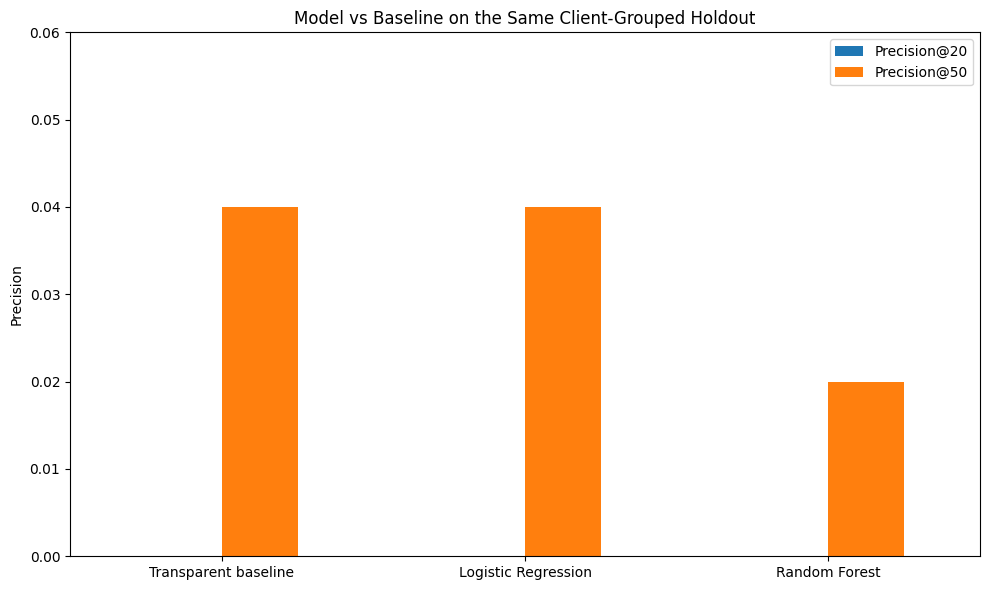

,Validation design,Precision@20,Overlapping clients
0,Random-row split,0.7,12
1,Client-grouped holdout,0.0,0


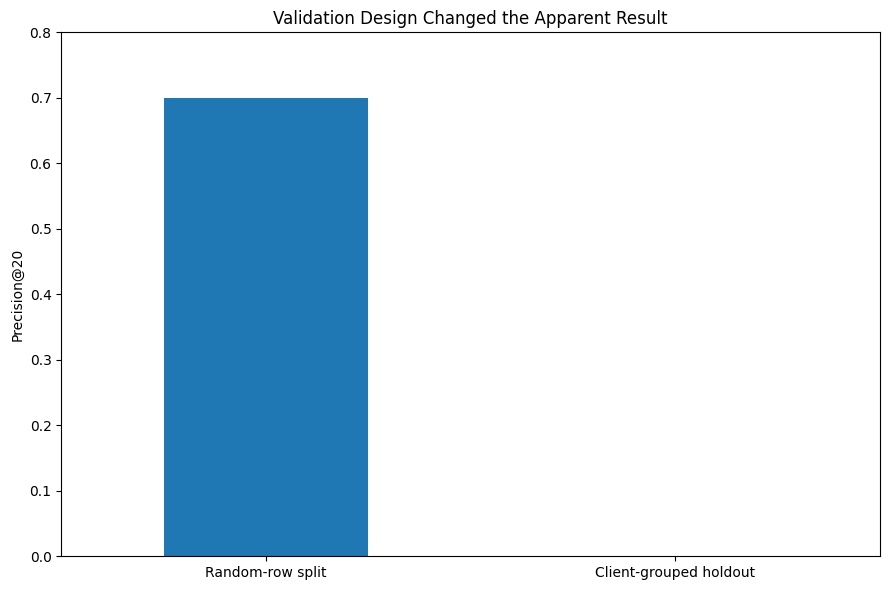

,Rank,Recommendation,Operational decision
0,1,Block automatic deployment,Do not automate page changes
1,2,Use a transparent review queue,Prioritize explainable historical signals
2,3,Assign review dispositions,"Use REVIEW, INVESTIGATE, TRIAGE, MONITOR or DEFER"
3,4,Treat freshness as a hypothesis,Require manual verification
4,5,Improve the feature set,Add only pre-decision and leakage-safe features
5,6,Run stronger validation,Use more clients and out-of-time testing
6,7,Measure real interventions,Track reviewed and untreated pages forward



All paper artifacts were generated successfully.
- /content/docs/assets/model-vs-baseline.png
- /content/docs/assets/validation-design-gap.png
- /content/docs/assets/data-summary.csv
- /content/docs/assets/model-results.csv
- /content/docs/assets/validation-comparison.csv
- /content/docs/assets/ranked-recommendations.csv

Public-safety reminder: manually inspect every chart, table and notebook output before deployment.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. Locate the repository and create the assets directory
# ---------------------------------------------------------

possible_roots = [
    Path("/content/flyrank-ml-internship"),
    Path.cwd()
]

repo_root = next(
    (
        path
        for path in possible_roots
        if (path / "work").exists()
    ),
    Path.cwd()
)

assets_dir = repo_root / "docs" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)

print("Repository root:", repo_root)
print("Artifact directory:", assets_dir)

# ---------------------------------------------------------
# 2. Data and validation summary
# ---------------------------------------------------------

data_summary = pd.DataFrame([
    ["Eligible client-content rows", 2348],
    ["Eligible pseudonymous clients", 14],
    ["Training rows", 2120],
    ["Training clients", 10],
    ["Test rows", 228],
    ["Unseen test clients", 4],
    ["Training-test client overlap", 0],
    ["Test positive base rate", 0.057],
    ["Historical feature count", 5],
    ["Primary metric", "Precision@20"]
], columns=["Item", "Value"])

display(data_summary)

# ---------------------------------------------------------
# 3. Honest model-versus-baseline results
# ---------------------------------------------------------

results = pd.DataFrame({
    "Method": [
        "Transparent baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision@20": [0.000, 0.000, 0.000],
    "Precision@50": [0.040, 0.040, 0.020],
    "Average Precision": [0.0478, 0.0461, 0.0591],
    "ROC-AUC": [0.3955, 0.3284, 0.5120]
})

display(results)

# ---------------------------------------------------------
# 4. Generate the model-versus-baseline chart
# ---------------------------------------------------------

precision_chart = results.set_index("Method")[
    ["Precision@20", "Precision@50"]
]

ax = precision_chart.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Model vs Baseline on the Same Client-Grouped Holdout"
)
ax.set_xlabel("")
ax.set_ylabel("Precision")
ax.set_ylim(0, 0.06)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

model_chart_path = (
    assets_dir / "model-vs-baseline.png"
)

plt.savefig(
    model_chart_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 5. Validation-design comparison
# ---------------------------------------------------------

validation_comparison = pd.DataFrame({
    "Validation design": [
        "Random-row split",
        "Client-grouped holdout"
    ],
    "Precision@20": [0.700, 0.000],
    "Overlapping clients": [12, 0]
})

display(validation_comparison)

ax = validation_comparison.plot(
    x="Validation design",
    y="Precision@20",
    kind="bar",
    legend=False,
    figsize=(9, 6)
)

ax.set_title(
    "Validation Design Changed the Apparent Result"
)
ax.set_xlabel("")
ax.set_ylabel("Precision@20")
ax.set_ylim(0, 0.80)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

validation_chart_path = (
    assets_dir / "validation-design-gap.png"
)

plt.savefig(
    validation_chart_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 6. Ranked recommendations artifact
# ---------------------------------------------------------

ranked_recommendations = pd.DataFrame([
    [
        1,
        "Block automatic deployment",
        "Do not automate page changes"
    ],
    [
        2,
        "Use a transparent review queue",
        "Prioritize explainable historical signals"
    ],
    [
        3,
        "Assign review dispositions",
        "Use REVIEW, INVESTIGATE, TRIAGE, MONITOR or DEFER"
    ],
    [
        4,
        "Treat freshness as a hypothesis",
        "Require manual verification"
    ],
    [
        5,
        "Improve the feature set",
        "Add only pre-decision and leakage-safe features"
    ],
    [
        6,
        "Run stronger validation",
        "Use more clients and out-of-time testing"
    ],
    [
        7,
        "Measure real interventions",
        "Track reviewed and untreated pages forward"
    ]
], columns=[
    "Rank",
    "Recommendation",
    "Operational decision"
])

display(ranked_recommendations)

# ---------------------------------------------------------
# 7. Export publication-ready CSV tables
# ---------------------------------------------------------

data_summary.to_csv(
    assets_dir / "data-summary.csv",
    index=False
)

results.to_csv(
    assets_dir / "model-results.csv",
    index=False
)

validation_comparison.to_csv(
    assets_dir / "validation-comparison.csv",
    index=False
)

ranked_recommendations.to_csv(
    assets_dir / "ranked-recommendations.csv",
    index=False
)

# ---------------------------------------------------------
# 8. Verify artifacts
# ---------------------------------------------------------

required_artifacts = [
    assets_dir / "model-vs-baseline.png",
    assets_dir / "validation-design-gap.png",
    assets_dir / "data-summary.csv",
    assets_dir / "model-results.csv",
    assets_dir / "validation-comparison.csv",
    assets_dir / "ranked-recommendations.csv"
]

missing_artifacts = [
    str(path)
    for path in required_artifacts
    if not path.exists()
]

assert not missing_artifacts, (
    "Missing artifacts: "
    + ", ".join(missing_artifacts)
)

print("\nAll paper artifacts were generated successfully.")

for artifact in required_artifacts:
    print("-", artifact)

print(
    "\nPublic-safety reminder: manually inspect every chart, "
    "table and notebook output before deployment."
)

## Self-Check

Before submitting this project, I completed the following checks:

* [x] The research question and supported decision are clearly defined.
* [x] The data source, table, unit of analysis, date windows, and eligibility rules are documented.
* [x] The feature window is March 1–21, 2026.
* [x] The outcome window is March 22–31, 2026.
* [x] The June 2026 period remained sealed and was not used during development.
* [x] The decline-proxy label is clearly defined.
* [x] Only pre-decision historical features are used by the honest models.
* [x] Outcome-window variables are excluded from the feature set.
* [x] The transparent baseline, Logistic Regression, and Random Forest are compared on the same client-grouped holdout.
* [x] Training and test clients have zero overlap.
* [x] Precision@20, Precision@50, Average Precision, ROC-AUC, and the test base rate are reported.
* [x] The random-row result is clearly identified as misleading because twelve clients overlapped between training and testing.
* [x] The honest client-grouped Precision@20 result of 0.000 is reported without hiding or exaggerating it.
* [x] The paper does not claim that the model is production-ready.
* [x] The paper does not claim that refreshing or modifying a page will cause traffic recovery.
* [x] Limitations and honest claim language are included.
* [x] Ranked recommendations and a human-review action playbook are included.
* [x] The required charts and result tables are included.
* [x] Links to the repository and supporting notebooks are included.
* [x] The Acknowledgments and Data Credit section includes the required FlyRank link.
* [x] No client names, domains, page URLs, raw queries, private keywords, or confidential business information are intentionally included.
* [x] No authentication tokens, passwords, secrets, or credentials are shown.
* [x] Client and content identifiers remain pseudonymized.
* [x] The notebook runs from top to bottom without errors.
* [x] The research page is suitable for public deployment.
* [x] The exact deployed URL will be stored as one line in `submission/paper_url.txt`.

### Final Submission Status

The research artifact presents directional evidence from one March 2026 experiment. It honestly reports that the evaluated models did not demonstrate useful Precision@20 performance on unseen clients.

The current model is retained only for research, auditing, and human-reviewed decision support. Automatic production deployment remains blocked.

The project is ready for deployment after the public URL, notebook links, charts, and `submission/paper_url.txt` entry are verified.


## Week-8 Showcase — 5-Minute Demo

### 0:00–0:45 — Question and FlyRank content problem

**Question:** Can historical search-performance signals help prioritize which client-content pages a human should investigate first when future impressions decline, especially for completely unseen clients?

**Context:** FlyRank's content workflow has to monitor many published pages because pages can quietly lose search visibility as rankings, clicks, and impressions change. This capstone treats that real content-operations problem as a ranking task: produce a small human-review queue instead of asking the model to publish or modify content automatically.

### 0:45–1:45 — Data and method

* Public-safe FlyRank Internship Warehouse release.
* 2,348 eligible client-content rows across 14 pseudonymous clients.
* Five historical, pre-decision features: impressions/day, clicks/day, CTR, average position, and position standard deviation.
* Label: outcome impressions/day < 80% of historical impressions/day.
* Models: transparent baseline, Logistic Regression, and constrained Random Forest.
* Primary metric: Precision@20.
* Final validation: client-grouped holdout with 2,120 training rows from 10 clients and 228 test rows from 4 completely unseen clients; client overlap = 0.

### 1:45–2:45 — One chart

Show **`docs/assets/model-vs-baseline.png`** from the completed notebook.

Explain the one message the audience should see: all three methods have Precision@20 of 0.000 on the same unseen-client holdout, while Precision@50 is 0.040 for the transparent baseline and Logistic Regression and 0.020 for Random Forest.

### 2:45–3:45 — One honest result

The random-row diagnostic initially produced Precision@20 of 0.700, but 12 clients appeared in both training and test. When client overlap was removed, Precision@20 became 0.000 for all three approaches. Therefore the grouped result is the primary evidence, and the study does **not** demonstrate useful operational lift for a Top-20 queue on unseen clients.

### 3:45–4:30 — One recommendation

**Recommendation:** keep automatic deployment blocked and use a transparent human-review queue while collecting stronger evidence. Every future feature should be pre-decision and leakage-safe, and future validation should include more clients plus out-of-time testing.

### 4:30–5:00 — Close

The takeaway is not that the idea failed; it is that the current evidence is not strong enough to automate a content decision. The next useful step is to expand leakage-safe signals, strengthen grouped and temporal validation, and measure what happens after real human-reviewed interventions.

## Shareable Cut 1 — Short Social Post

I built a public-safe ML research workflow around a real FlyRank content problem: when search performance starts to decay across many published pages, which pages should a human investigate first?

I tested five historical search-performance features against a transparent baseline, Logistic Regression, and Random Forest, using a client-grouped holdout so no client appeared in both training and test. The key lesson was methodological: a random-row split showed Precision@20 = 0.700, but that result was misleading because 12 clients overlapped; the honest unseen-client holdout gave Precision@20 = 0.000 for every method.

That means the current evidence supports human-reviewed prioritization, not automatic content changes. Paper and reproducible notebooks: https://cyb3rvigil.github.io/flyrank-ml-internship/

## Shareable Cut 2 — Employer Summary

I built a public-safe ML research pipeline to prioritize client-content pages that may experience future impression decline, using 2,348 eligible rows from 14 pseudonymous clients and five historical search-performance features. I compared a transparent baseline, Logistic Regression, and Random Forest using a client-grouped holdout with four completely unseen test clients. The honest result was that all three methods achieved Precision@20 of 0.000, so the project recommends human-reviewed decision support and stronger grouped/time-based validation rather than automatic deployment.
